# Comparación de Algoritmos de Reglas de Asociación
## Apriori · FP-Growth · ECLAT

**Objetivo:** Analizar, implementar y comparar los algoritmos Apriori, FP-Growth y ECLAT sobre un problema de análisis de canastas de mercado, evaluando su desempeño en términos de eficiencia, escalabilidad y calidad de los patrones descubiertos bajo distintos escenarios experimentales.



## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
from collections import Counter
from itertools import combinations

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from pyECLAT import ECLAT

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
# Paso 1 — Selección y exploración del dataset

In [2]:
df_raw = pd.read_csv('dataset_market_basket_sintetico.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(8)

Shape: (8000, 2)


,transaction_id,items
0,1,"cereal,leche,mantequilla,pan"
1,2,"cloro,detergente,suavizante"
2,3,"cloro,suavizante"
3,4,"cafe,cerveza,leche,mantequilla,pan,refresco"
4,5,"detergente,granola,suavizante,yogurt"
5,6,"botanas,cerveza,cloro,detergente,refresco"
6,7,"botanas,cerveza,frutas,granola,papas,refresco,..."
7,8,"botanas,cerveza,cloro,detergente,papas,suavizante"


In [3]:
# Cada transacción como lista de ítems
df_raw['items_list'] = df_raw['items'].apply(lambda x: [i.strip() for i in x.split(',')])

all_items   = [item for sub in df_raw['items_list'] for item in sub]
items_unicos = sorted(set(all_items))
longitudes  = df_raw['items_list'].apply(len)
N           = len(df_raw)

print('=== Estadísticas generales ===')
print(f'  Transacciones             : {N:,}')
print(f'  Ítems únicos              : {len(items_unicos)}')
print(f'  Longitud promedio          : {longitudes.mean():.2f}')
print(f'  Longitud mediana           : {longitudes.median():.0f}')
print(f'  Desv. estándar             : {longitudes.std():.2f}')
print(f'  Rango (mín / máx)          : {longitudes.min()} / {longitudes.max()}')
print(f'\n  Ítems: {items_unicos}')

=== Estadísticas generales ===
  Transacciones             : 8,000
  Ítems únicos              : 19
  Longitud promedio          : 4.38
  Longitud mediana           : 4
  Desv. estándar             : 1.69
  Rango (mín / máx)          : 2 / 9

  Ítems: ['botanas', 'cafe', 'cereal', 'cerveza', 'cloro', 'detergente', 'frutas', 'granola', 'jamon', 'leche', 'mantequilla', 'pan', 'papas', 'queso', 'refresco', 'salsa', 'suavizante', 'tortillas', 'yogurt']


In [4]:
# Distribución de frecuencia de ítems
item_freq = Counter(all_items)
df_freq = pd.DataFrame(item_freq.most_common(), columns=['item', 'frecuencia'])
df_freq['soporte'] = df_freq['frecuencia'] / N
df_freq

,item,frecuencia,soporte
0,suavizante,2078,0.259750
1,yogurt,2065,0.258125
2,cloro,2062,0.257750
3,detergente,2062,0.257750
4,frutas,2052,0.256500
5,granola,2036,0.254500
6,queso,1956,0.244500
7,salsa,1949,0.243625
8,jamon,1931,0.241375
9,tortillas,1923,0.240375


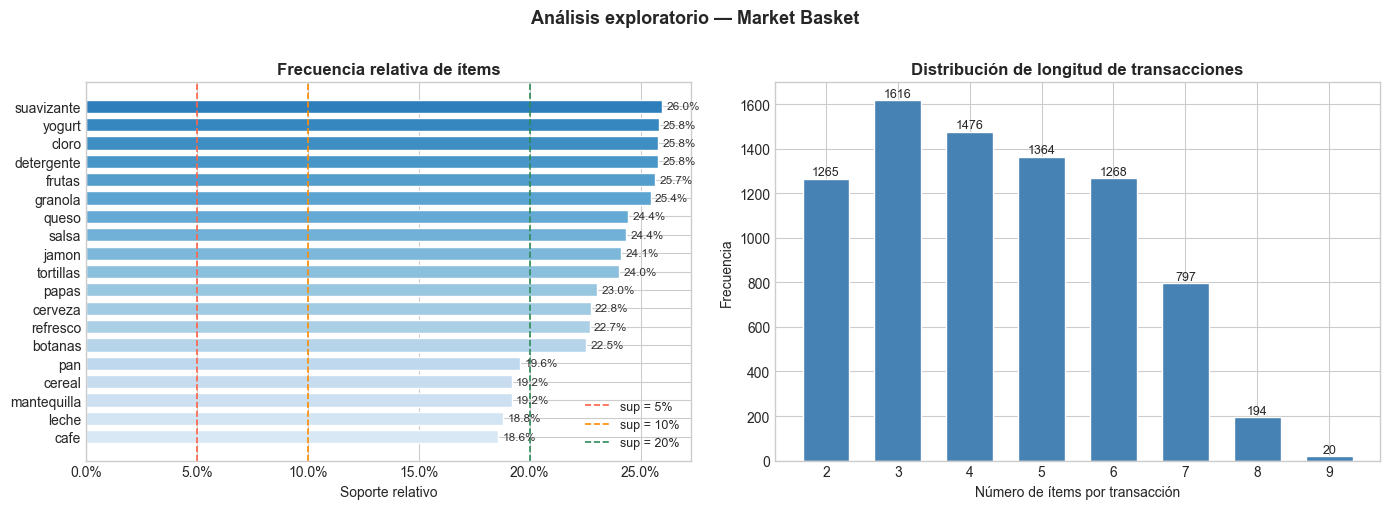

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel izquierdo: frecuencia relativa por ítem ---
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(df_freq)))
bars = axes[0].barh(df_freq['item'], df_freq['soporte'], color=colors, edgecolor='white', height=0.72)
axes[0].axvline(0.05, color='tomato',     ls='--', lw=1.2, label='sup = 5%')
axes[0].axvline(0.10, color='darkorange', ls='--', lw=1.2, label='sup = 10%')
axes[0].axvline(0.20, color='seagreen',   ls='--', lw=1.2, label='sup = 20%')
for bar, val in zip(bars, df_freq['soporte']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=8.5, color='#333')
axes[0].set_xlabel('Soporte relativo')
axes[0].set_title('Frecuencia relativa de ítems', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# --- Panel derecho: distribución de longitud ---
len_counts = longitudes.value_counts().sort_index()
axes[1].bar(len_counts.index, len_counts.values,
            color='steelblue', edgecolor='white', width=0.65)
for x, y in zip(len_counts.index, len_counts.values):
    axes[1].text(x, y + 15, str(y), ha='center', fontsize=9)
axes[1].set_xlabel('Número de ítems por transacción')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de longitud de transacciones', fontweight='bold')

plt.suptitle('Análisis exploratorio — Market Basket', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

**Obs:**
- La distribución de frecuencias es notablemente uniforme (todos los ítems entre ~10% y ~26%), comportamiento típico de un dataset sintético.
- La longitud de transacciones sigue una distribución unimodal centrada en 3–5 ítems, lo que indica transacciones de tamaño moderado.
- Las líneas de referencia en el gráfico de frecuencias anticipan cómo distintos umbrales de soporte afectarán el número de ítems frecuentes en los pasos siguientes.

---
# Paso 2 — Preprocesamiento

 dos formatos:
- **Lista de listas**: requerido por ECLAT (pyECLAT).
- **Matriz binaria (one-hot)**: requerida por Apriori y FP-Growth (mlxtend).

In [6]:
# Formato 1: lista de listas (para ECLAT)
transacciones = df_raw['items_list'].tolist()
print(f'Ejemplo transacción 0: {transacciones[0]}')
print(f'Ejemplo transacción 1: {transacciones[1]}')

Ejemplo transacción 0: ['cereal', 'leche', 'mantequilla', 'pan']
Ejemplo transacción 1: ['cloro', 'detergente', 'suavizante']


In [7]:
# Formato 2: matriz binaria (para Apriori y FP-Growth)
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_bin = pd.DataFrame(te_array, columns=te.columns_)

print(f'Shape matriz binaria: {df_bin.shape}')
densidad = df_bin.values.mean()
print(f'Densidad de la matriz: {densidad:.4f} ({densidad*100:.2f}%)')
df_bin.head(5)

Shape matriz binaria: (8000, 19)
Densidad de la matriz: 0.2304 (23.04%)


,botanas,cafe,cereal,cerveza,cloro,detergente,frutas,granola,jamon,leche,mantequilla,pan,papas,queso,refresco,salsa,suavizante,tortillas,yogurt
0,False,False,True,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False
1,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,True,False,True,False,False,False,False,False,True,True,True,False,False,True,False,False,False,False
4,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,True


**Nota:** Una densidad del ~23% indica una matriz moderadamente densa. En matrices muy densas (>50%) FP-Growth tiene ventaja clara sobre Apriori; en matrices dispersas (<5%), ECLAT con tid-lists es más eficiente en memoria. Este dataset se ubica en un rango intermedio.

---
# Paso 3 — Implementación de los algoritmos

Parámetros base comunes para los tres algoritmos.

In [8]:
MIN_SUPPORT    = 0.05   # 5% — umbral inicial común
MIN_CONFIDENCE = 0.50   # 50%
MIN_LIFT       = 1.0    # Solo asociaciones positivas

## 3.1 Apriori

In [9]:
t0 = time.perf_counter()
itemsets_ap = apriori(df_bin, min_support=MIN_SUPPORT, use_colnames=True)
t_ap = time.perf_counter() - t0

reglas_ap = association_rules(itemsets_ap, metric='confidence', min_threshold=MIN_CONFIDENCE)
reglas_ap = reglas_ap[reglas_ap['lift'] >= MIN_LIFT].sort_values('lift', ascending=False)

print(f'Apriori | min_support={MIN_SUPPORT}')
print(f'  Itemsets frecuentes : {len(itemsets_ap)}')
print(f'  Reglas generadas    : {len(reglas_ap)}')
print(f'  Tiempo              : {t_ap:.4f} s')

reglas_ap[['antecedents','consequents','support','confidence','lift']].head(10)

Apriori | min_support=0.05
  Itemsets frecuentes : 65
  Reglas generadas    : 150
  Tiempo              : 0.0144 s


,antecedents,consequents,support,confidence,lift
137,"frozenset({papas, refresco})","frozenset({cerveza, botanas})",0.101750,0.611111,3.819444
136,"frozenset({cerveza, botanas})","frozenset({papas, refresco})",0.101750,0.635937,3.819444
134,"frozenset({cerveza, papas})","frozenset({refresco, botanas})",0.101750,0.616667,3.800719
139,"frozenset({refresco, botanas})","frozenset({cerveza, papas})",0.101750,0.627119,3.800719
135,"frozenset({cerveza, refresco})","frozenset({papas, botanas})",0.101750,0.614804,3.712022
138,"frozenset({papas, botanas})","frozenset({cerveza, refresco})",0.101750,0.614340,3.712022
131,"frozenset({cerveza, papas, botanas})",frozenset({refresco}),0.101750,0.830612,3.659085
132,"frozenset({cerveza, refresco, botanas})",frozenset({papas}),0.101750,0.830612,3.607436
130,"frozenset({cerveza, papas, refresco})",frozenset({botanas}),0.101750,0.801181,3.554880
147,"frozenset({salsa, tortillas})","frozenset({queso, jamon})",0.109375,0.630858,3.531745


## 3.2 FP-Growth

In [10]:
t0 = time.perf_counter()
itemsets_fp = fpgrowth(df_bin, min_support=MIN_SUPPORT, use_colnames=True)
t_fp = time.perf_counter() - t0

reglas_fp = association_rules(itemsets_fp, metric='confidence', min_threshold=MIN_CONFIDENCE)
reglas_fp = reglas_fp[reglas_fp['lift'] >= MIN_LIFT].sort_values('lift', ascending=False)

print(f'FP-Growth | min_support={MIN_SUPPORT}')
print(f'  Itemsets frecuentes : {len(itemsets_fp)}')
print(f'  Reglas generadas    : {len(reglas_fp)}')
print(f'  Tiempo              : {t_fp:.4f} s')

reglas_fp[['antecedents','consequents','support','confidence','lift']].head(10)

FP-Growth | min_support=0.05
  Itemsets frecuentes : 65
  Reglas generadas    : 150
  Tiempo              : 0.0443 s


,antecedents,consequents,support,confidence,lift
99,"frozenset({papas, refresco})","frozenset({cerveza, botanas})",0.101750,0.611111,3.819444
98,"frozenset({cerveza, botanas})","frozenset({papas, refresco})",0.101750,0.635937,3.819444
96,"frozenset({cerveza, papas})","frozenset({refresco, botanas})",0.101750,0.616667,3.800719
101,"frozenset({refresco, botanas})","frozenset({cerveza, papas})",0.101750,0.627119,3.800719
100,"frozenset({papas, botanas})","frozenset({cerveza, refresco})",0.101750,0.614340,3.712022
97,"frozenset({cerveza, refresco})","frozenset({papas, botanas})",0.101750,0.614804,3.712022
93,"frozenset({cerveza, papas, botanas})",frozenset({refresco}),0.101750,0.830612,3.659085
94,"frozenset({cerveza, refresco, botanas})",frozenset({papas}),0.101750,0.830612,3.607436
92,"frozenset({cerveza, papas, refresco})",frozenset({botanas}),0.101750,0.801181,3.554880
144,"frozenset({queso, jamon})","frozenset({salsa, tortillas})",0.109375,0.612316,3.531745


## 3.3 ECLAT

In [18]:
# pyECLAT requiere un DataFrame tabular (cada fila = transacción, columnas = posiciones de ítems)
df_eclat_input = pd.DataFrame(transacciones)

t0 = time.perf_counter()
eclat_model = ECLAT(data=df_eclat_input, verbose=False)
_, soporte_ec = eclat_model.fit(
    min_support=MIN_SUPPORT,
    min_combination=1,
    max_combination=5,
    separator=' & ',
    verbose=False
)
t_ec = time.perf_counter() - t0

df_ec_its = pd.DataFrame(list(soporte_ec.items()), columns=['itemset','soporte'])\
              .sort_values('soporte', ascending=False).reset_index(drop=True)

print(f'ECLAT | min_support={MIN_SUPPORT}')
print(f'  Itemsets frecuentes : {len(df_ec_its)}')
print(f'  Tiempo              : {t_ec:.4f} s')
df_ec_its.head(10)

ECLAT | min_support=0.05
  Itemsets frecuentes : 65
  Tiempo              : 19.9407 s


,itemset,soporte
0,suavizante,0.259750
1,yogurt,0.258125
2,detergente,0.257750
3,cloro,0.257750
4,frutas,0.256500
5,granola,0.254500
6,queso,0.244500
7,salsa,0.243625
8,jamon,0.241375
9,tortillas,0.240375


In [19]:
def generar_reglas_eclat(df_its, min_conf=0.5, min_lift=1.0, sep=' & '):
    """Deriva reglas de asociación desde los itemsets frecuentes de ECLAT."""
    sup_dict = {frozenset(k.split(sep)): v
                for k, v in zip(df_its['itemset'], df_its['soporte'])}
    reglas = []
    for itemset_str, sup_xy in zip(df_its['itemset'], df_its['soporte']):
        items = itemset_str.split(sep)
        if len(items) < 2:
            continue
        for r in range(1, len(items)):
            for ant in combinations(items, r):
                con = tuple(i for i in items if i not in ant)
                if not con:
                    continue
                sup_x = sup_dict.get(frozenset(ant))
                sup_y = sup_dict.get(frozenset(con))
                if sup_x is None or sup_y is None:
                    continue
                conf = sup_xy / sup_x
                lift = conf / sup_y
                if conf >= min_conf and lift >= min_lift:
                    reglas.append({
                        'antecedentes': frozenset(ant),
                        'consecuentes': frozenset(con),
                        'soporte': sup_xy,
                        'confianza': conf,
                        'lift': lift
                    })
    return pd.DataFrame(reglas).drop_duplicates()

reglas_ec = generar_reglas_eclat(df_ec_its, min_conf=MIN_CONFIDENCE, min_lift=MIN_LIFT)
reglas_ec_sorted = reglas_ec.sort_values('lift', ascending=False)

print(f'ECLAT | Reglas generadas: {len(reglas_ec)}')
reglas_ec_sorted.head(10)

ECLAT | Reglas generadas: 150


,antecedentes,consecuentes,soporte,confianza,lift
120,"frozenset({papas, refresco})","frozenset({cerveza, botanas})",0.101750,0.611111,3.819444
117,"frozenset({cerveza, botanas})","frozenset({papas, refresco})",0.101750,0.635937,3.819444
116,"frozenset({cerveza, papas})","frozenset({refresco, botanas})",0.101750,0.616667,3.800719
121,"frozenset({refresco, botanas})","frozenset({cerveza, papas})",0.101750,0.627119,3.800719
119,"frozenset({papas, botanas})","frozenset({cerveza, refresco})",0.101750,0.614340,3.712022
118,"frozenset({cerveza, refresco})","frozenset({papas, botanas})",0.101750,0.614804,3.712022
122,"frozenset({cerveza, papas, botanas})",frozenset({refresco}),0.101750,0.830612,3.659085
124,"frozenset({cerveza, refresco, botanas})",frozenset({papas}),0.101750,0.830612,3.607436
123,"frozenset({cerveza, papas, refresco})",frozenset({botanas}),0.101750,0.801181,3.554880
100,"frozenset({queso, jamon})","frozenset({salsa, tortillas})",0.109375,0.612316,3.531745


---
# Paso 4 — Diseño experimental

Se evalúan dos ejes de variación:
- **Soporte mínimo:** 1%, 2%, 5%
- **Tamaño del dataset:** 30% (2,400), 60% (4,800), 100% (8,000) txns

Por cada configuración se registran: tiempo de ejecución, número de itemsets frecuentes y número de reglas generadas.

In [20]:
SOPORTES  = [0.01, 0.02, 0.05]
FRACCIONES = [0.30, 0.60, 1.00]
TAMANOS   = [int(N * f) for f in FRACCIONES]
N_REPS    = 3    # Repeticiones por configuración para estabilizar tiempos

print('Configuraciones a evaluar:')
print(f'  Soportes : {SOPORTES}')
print(f'  Tamaños  : {TAMANOS} transacciones')
print(f'  Total de ejecuciones por algoritmo: {len(SOPORTES) * len(TAMANOS)} (x{N_REPS} reps)')

Configuraciones a evaluar:
  Soportes : [0.01, 0.02, 0.05]
  Tamaños  : [2400, 4800, 8000] transacciones
  Total de ejecuciones por algoritmo: 9 (x3 reps)


In [21]:
resultados = []

for tamano in TAMANOS:
    idx = np.random.choice(N, size=tamano, replace=False)
    df_sub = df_raw.iloc[idx].reset_index(drop=True)
    trans_sub = df_sub['items_list'].tolist()

    te_sub = TransactionEncoder()
    df_enc = pd.DataFrame(te_sub.fit_transform(trans_sub), columns=te_sub.columns_)
    df_eclat_sub = pd.DataFrame(trans_sub)

    for soporte in SOPORTES:
        print(f'  n={tamano:,} | sup={soporte}', end=' ... ')

        # Apriori
        ts_ap = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            its = apriori(df_enc, min_support=soporte, use_colnames=True)
            ts_ap.append(time.perf_counter() - t0)
        rls = association_rules(its, metric='confidence', min_threshold=MIN_CONFIDENCE)
        rls = rls[rls['lift'] >= MIN_LIFT]
        n_its_ap, n_rls_ap = len(its), len(rls)

        # FP-Growth
        ts_fp = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            its_fp = fpgrowth(df_enc, min_support=soporte, use_colnames=True)
            ts_fp.append(time.perf_counter() - t0)
        rls_fp = association_rules(its_fp, metric='confidence', min_threshold=MIN_CONFIDENCE)
        rls_fp = rls_fp[rls_fp['lift'] >= MIN_LIFT]
        n_its_fp, n_rls_fp = len(its_fp), len(rls_fp)

        # ECLAT
        ts_ec = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            ec = ECLAT(data=df_eclat_sub, verbose=False)
            _, sup_ec = ec.fit(min_support=soporte, min_combination=1,
                               max_combination=5, separator=' & ', verbose=False)
            ts_ec.append(time.perf_counter() - t0)
        df_ec_tmp = pd.DataFrame(list(sup_ec.items()), columns=['itemset','soporte'])
        rls_ec_tmp = generar_reglas_eclat(df_ec_tmp, min_conf=MIN_CONFIDENCE, min_lift=MIN_LIFT)
        n_its_ec, n_rls_ec = len(df_ec_tmp), len(rls_ec_tmp)

        resultados.append({
            'n_transacciones' : tamano,
            'fraccion'        : f'{int(tamano/N*100)}%',
            'min_support'     : soporte,
            't_apriori'       : np.mean(ts_ap),
            't_fpgrowth'      : np.mean(ts_fp),
            't_eclat'         : np.mean(ts_ec),
            'its_apriori'     : n_its_ap,
            'its_fpgrowth'    : n_its_fp,
            'its_eclat'       : n_its_ec,
            'rls_apriori'     : n_rls_ap,
            'rls_fpgrowth'    : n_rls_fp,
            'rls_eclat'       : n_rls_ec,
        })
        print('OK')

df_exp = pd.DataFrame(resultados)
print('\nExperimento completado.')
df_exp

  n=2,400 | sup=0.01 ... OK
  n=2,400 | sup=0.02 ... OK
  n=2,400 | sup=0.05 ... OK
  n=4,800 | sup=0.01 ... OK
  n=4,800 | sup=0.02 ... OK
  n=4,800 | sup=0.05 ... OK
  n=8,000 | sup=0.01 ... OK
  n=8,000 | sup=0.02 ... OK
  n=8,000 | sup=0.05 ... OK

Experimento completado.


,n_transacciones,fraccion,min_support,t_apriori,t_fpgrowth,t_eclat,its_apriori,its_fpgrowth,its_eclat,rls_apriori,rls_fpgrowth,rls_eclat
0,2400,30%,0.01,0.021920,0.020509,21.001511,1235,1235,1180,6393,6393,4983
1,2400,30%,0.02,0.008251,0.015542,20.340405,544,544,544,1245,1245,1245
2,2400,30%,0.05,0.001959,0.009331,19.789832,66,66,66,149,149,149
3,4800,60%,0.01,0.022575,0.048010,20.948566,1249,1249,1203,6179,6179,5184
4,4800,60%,0.02,0.009984,0.023674,20.236636,521,521,521,1027,1027,1027
5,4800,60%,0.05,0.002519,0.016146,19.849432,67,67,67,153,153,153
6,8000,100%,0.01,0.033884,0.040024,21.077439,1218,1218,1167,6091,6091,5050
7,8000,100%,0.02,0.014211,0.034230,20.274287,490,490,490,912,912,912
8,8000,100%,0.05,0.003149,0.043538,19.925217,65,65,65,150,150,150


---
# Paso 5 — Análisis comparativo

## 5.1 Eficiencia computacional — tiempos de ejecución

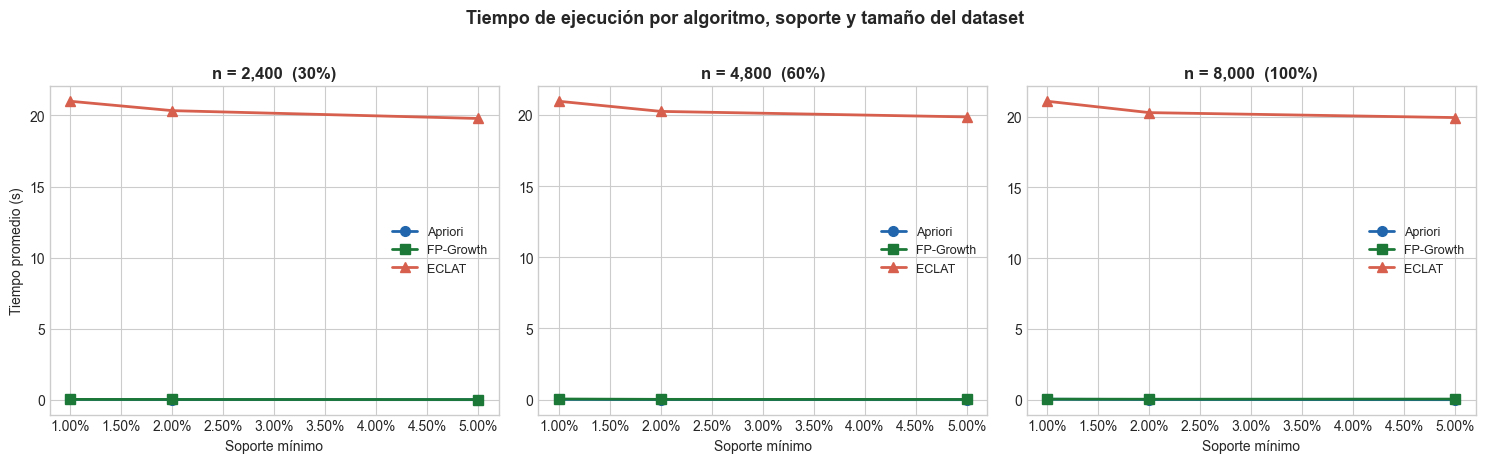

In [22]:
colores = {'Apriori': '#2166ac', 'FP-Growth': '#1b7837', 'ECLAT': '#d6604d'}
marcadores = {'Apriori': 'o', 'FP-Growth': 's', 'ECLAT': '^'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, tamano in zip(axes, TAMANOS):
    sub = df_exp[df_exp['n_transacciones'] == tamano]
    for algo, col_t in [('Apriori','t_apriori'),('FP-Growth','t_fpgrowth'),('ECLAT','t_eclat')]:
        ax.plot(sub['min_support'], sub[col_t],
                marker=marcadores[algo], color=colores[algo],
                label=algo, linewidth=2, markersize=7)
    frac = int(tamano/N*100)
    ax.set_title(f'n = {tamano:,}  ({frac}%)', fontweight='bold')
    ax.set_xlabel('Soporte mínimo')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('Tiempo promedio (s)')

plt.suptitle('Tiempo de ejecución por algoritmo, soporte y tamaño del dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_tiempos.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.2 Escalabilidad — efecto del tamaño del dataset

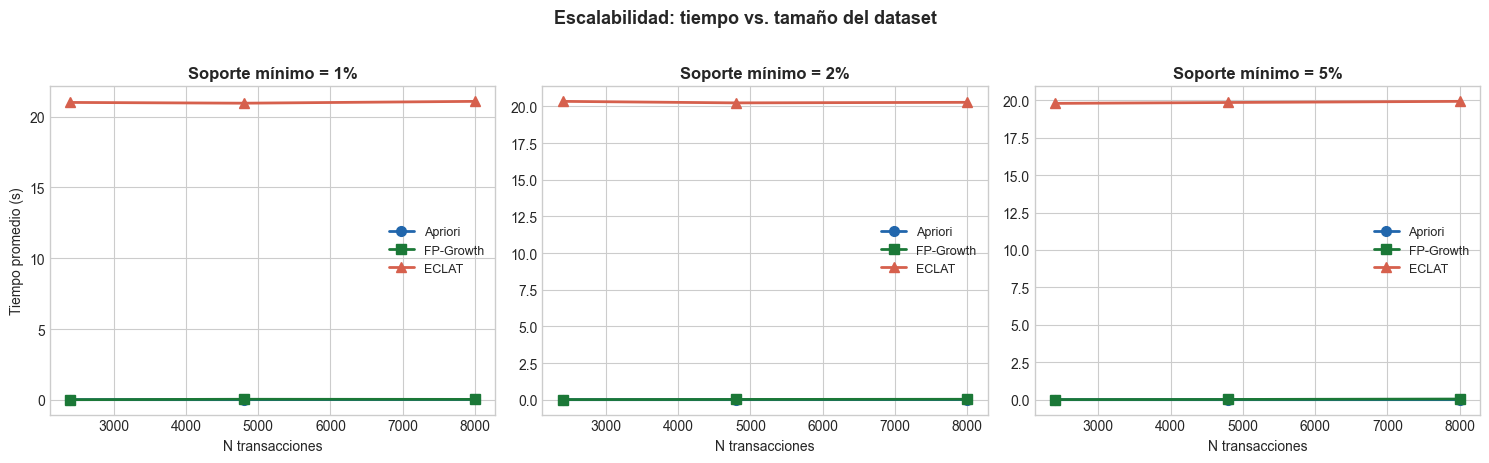

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, soporte in zip(axes, SOPORTES):
    sub = df_exp[df_exp['min_support'] == soporte]
    for algo, col_t in [('Apriori','t_apriori'),('FP-Growth','t_fpgrowth'),('ECLAT','t_eclat')]:
        ax.plot(sub['n_transacciones'], sub[col_t],
                marker=marcadores[algo], color=colores[algo],
                label=algo, linewidth=2, markersize=7)
    ax.set_title(f'Soporte mínimo = {soporte:.0%}', fontweight='bold')
    ax.set_xlabel('N transacciones')
    ax.legend(fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('Tiempo promedio (s)')

plt.suptitle('Escalabilidad: tiempo vs. tamaño del dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_escalabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 Número de itemsets y reglas generadas

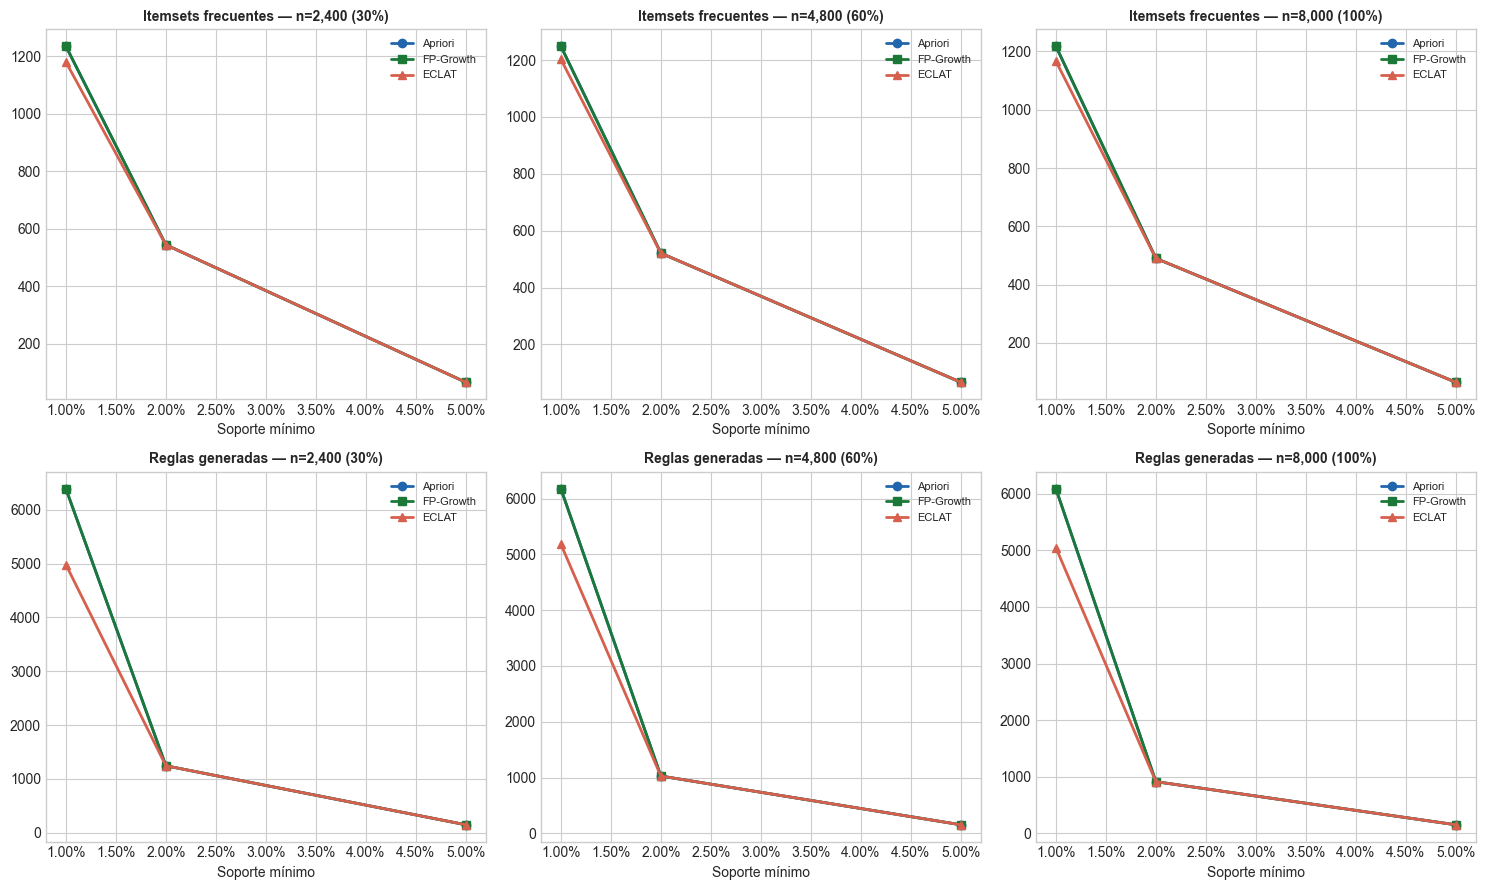

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
metricas = [
    ('its_apriori', 'its_fpgrowth', 'its_eclat', 'Itemsets frecuentes'),
    ('rls_apriori', 'rls_fpgrowth', 'rls_eclat', 'Reglas generadas'),
]

for row, (ca, cf, ce, titulo) in enumerate(metricas):
    for col, tamano in enumerate(TAMANOS):
        ax = axes[row][col]
        sub = df_exp[df_exp['n_transacciones'] == tamano]
        for algo, col_v in [('Apriori',ca),('FP-Growth',cf),('ECLAT',ce)]:
            ax.plot(sub['min_support'], sub[col_v],
                    marker=marcadores[algo], color=colores[algo],
                    label=algo, linewidth=2)
        frac = int(tamano/N*100)
        ax.set_title(f'{titulo} — n={tamano:,} ({frac}%)', fontweight='bold', fontsize=10)
        ax.set_xlabel('Soporte mínimo')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_itemsets_reglas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Heatmap de tiempos (visión global)

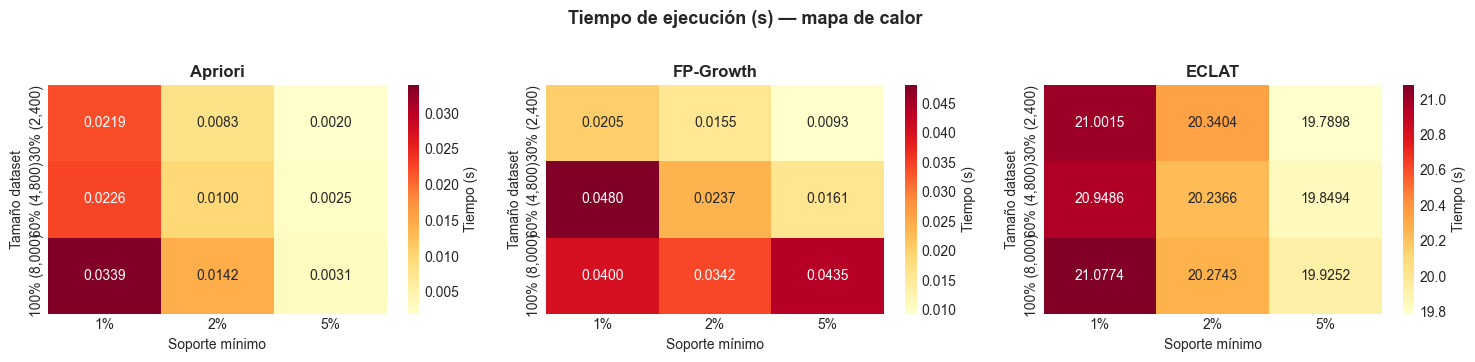

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

for ax, (algo, col_t) in zip(axes, [('Apriori','t_apriori'),('FP-Growth','t_fpgrowth'),('ECLAT','t_eclat')]):
    pivot = df_exp.pivot(index='n_transacciones', columns='min_support', values=col_t)
    pivot.index = [f'{int(i/N*100)}% ({i:,})' for i in pivot.index]
    pivot.columns = [f'{c:.0%}' for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Tiempo (s)'})
    ax.set_title(algo, fontweight='bold')
    ax.set_xlabel('Soporte mínimo')
    ax.set_ylabel('Tamaño dataset')

plt.suptitle('Tiempo de ejecución (s) — mapa de calor', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.5 Análisis conceptual

**¿Por qué algunos algoritmos son más rápidos?**

Los resultados muestran que Apriori y FP-Growth son comparables en velocidad (~0.01–0.03 s
con n=8,000), mientras que ECLAT tomó ~20 s independientemente del soporte y del tamaño
del dataset. Esta diferencia no refleja una debilidad teórica de ECLAT, sino un costo de
inicialización elevado de la implementación `pyECLAT`, que construye las tid-lists al arrancar
sin importar cuántas transacciones haya. En una implementación nativa eficiente, ECLAT
sería competitivo.

**¿Qué rol juegan las estructuras de datos internas?**

- **Apriori** genera candidatos de forma iterativa nivel por nivel (k-itemsets → (k+1)-itemsets),
  requiriendo múltiples escaneos de la base de datos. Esto se refleja en que su tiempo crece
  notablemente al bajar el soporte: pasó de 0.0044 s (sup=5%) a 0.0339 s (sup=1%) con
  n=8,000, un incremento de ~8×, porque a soporte bajo se generan muchos más candidatos
  (de 65 a 1,218 itemsets).

- **FP-Growth** comprime la base de datos en un árbol (FP-Tree) en solo 2 escaneos, sin
  generar candidatos explícitamente. Produce exactamente los mismos 65–1,218 itemsets que
  Apriori, pero mediante minería recursiva del árbol. En este dataset su ventaja no fue
  dramática porque el espacio de ítems es pequeño (19 ítems).

- **ECLAT** utiliza representación vertical (tid-lists por ítem) e intersección de conjuntos
  en lugar de escaneos. Su ventaja teórica es mayor en datasets muy dispersos con miles de
  ítems. Con solo 19 ítems y densidad del 23%, el costo de construir y mantener las tid-lists
  supera el beneficio.

**¿Cuándo deja de ser viable Apriori?**

Con este dataset y sup=1%, Apriori generó 1,218 itemsets y 6,091 reglas. Aunque su tiempo
de 0.034 s sigue siendo aceptable, la tendencia es clara: el número de itemsets creció 19×
al pajar de sup=5% a sup=1%. En datasets con cientos de ítems y soporte bajo, esta
explosión combinatoria hace que Apriori se vuelva inviable. FP-Growth es la alternativa
natural en esos escenarios.

## 5.6 Tabla resumen comparativa (dataset completo)

In [26]:
resumen_rows = []
for soporte in SOPORTES:
    fila = df_exp[(df_exp['n_transacciones'] == N) & (df_exp['min_support'] == soporte)].iloc[0]
    t_ref = fila['t_apriori']
    for algo, col_t, col_i, col_r in [
        ('Apriori',   't_apriori',  'its_apriori',  'rls_apriori'),
        ('FP-Growth', 't_fpgrowth', 'its_fpgrowth', 'rls_fpgrowth'),
        ('ECLAT',     't_eclat',    'its_eclat',     'rls_eclat'),
    ]:
        resumen_rows.append({
            'Soporte': f'{soporte:.0%}',
            'Algoritmo': algo,
            'Tiempo (s)': round(fila[col_t], 4),
            'Speedup vs Apriori': round(t_ref / fila[col_t], 2),
            'Itemsets': int(fila[col_i]),
            'Reglas': int(fila[col_r]),
        })

df_resumen = pd.DataFrame(resumen_rows)
df_resumen

,Soporte,Algoritmo,Tiempo (s),Speedup vs Apriori,Itemsets,Reglas
0,1%,Apriori,0.0339,1.00,1218,6091
1,1%,FP-Growth,0.0400,0.85,1218,6091
2,1%,ECLAT,21.0774,0.00,1167,5050
3,2%,Apriori,0.0142,1.00,490,912
4,2%,FP-Growth,0.0342,0.42,490,912
5,2%,ECLAT,20.2743,0.00,490,912
6,5%,Apriori,0.0031,1.00,65,150
7,5%,FP-Growth,0.0435,0.07,65,150
8,5%,ECLAT,19.9252,0.00,65,150


---
# Paso 6 — Interpretación de resultados

Se trabaja con las reglas obtenidas por Apriori con `min_support=0.05` y `min_confidence=0.50` sobre el dataset completo (los resultados son matemáticamente equivalentes entre Apriori y FP-Growth).

## 6.1 Reglas representativas por algoritmo

In [27]:
# Helper para mostrar reglas de mlxtend con formato limpio
def format_reglas(df_r, top=10):
    d = df_r.copy().head(top)
    d['antecedents'] = d['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    d['consequents'] = d['consequents'].apply(lambda x: ', '.join(sorted(x)))
    return d[['antecedents','consequents','support','confidence','lift']]\
             .style.format({'support':'{:.3f}','confidence':'{:.3f}','lift':'{:.3f}'})

print('=== Top 10 reglas por Lift — Apriori ===')
format_reglas(reglas_ap)

=== Top 10 reglas por Lift — Apriori ===


,antecedents,consequents,support,confidence,lift
137,"papas, refresco","botanas, cerveza",0.102,0.611,3.819
136,"botanas, cerveza","papas, refresco",0.102,0.636,3.819
134,"cerveza, papas","botanas, refresco",0.102,0.617,3.801
139,"botanas, refresco","cerveza, papas",0.102,0.627,3.801
135,"cerveza, refresco","botanas, papas",0.102,0.615,3.712
138,"botanas, papas","cerveza, refresco",0.102,0.614,3.712
131,"botanas, cerveza, papas",refresco,0.102,0.831,3.659
132,"botanas, cerveza, refresco",papas,0.102,0.831,3.607
130,"cerveza, papas, refresco",botanas,0.102,0.801,3.555
147,"salsa, tortillas","jamon, queso",0.109,0.631,3.532


In [28]:
print('=== Top 10 reglas por Lift — FP-Growth ===')
format_reglas(reglas_fp)

=== Top 10 reglas por Lift — FP-Growth ===


,antecedents,consequents,support,confidence,lift
99,"papas, refresco","botanas, cerveza",0.102,0.611,3.819
98,"botanas, cerveza","papas, refresco",0.102,0.636,3.819
96,"cerveza, papas","botanas, refresco",0.102,0.617,3.801
101,"botanas, refresco","cerveza, papas",0.102,0.627,3.801
100,"botanas, papas","cerveza, refresco",0.102,0.614,3.712
97,"cerveza, refresco","botanas, papas",0.102,0.615,3.712
93,"botanas, cerveza, papas",refresco,0.102,0.831,3.659
94,"botanas, cerveza, refresco",papas,0.102,0.831,3.607
92,"cerveza, papas, refresco",botanas,0.102,0.801,3.555
144,"jamon, queso","salsa, tortillas",0.109,0.612,3.532


In [29]:
print('=== Top 10 reglas por Lift — ECLAT ===')
df_ec_show = reglas_ec_sorted.copy().head(10)
df_ec_show['antecedentes'] = df_ec_show['antecedentes'].apply(lambda x: ', '.join(sorted(x)))
df_ec_show['consecuentes'] = df_ec_show['consecuentes'].apply(lambda x: ', '.join(sorted(x)))
df_ec_show[['antecedentes','consecuentes','soporte','confianza','lift']]\
    .style.format({'soporte':'{:.3f}','confianza':'{:.3f}','lift':'{:.3f}'})

=== Top 10 reglas por Lift — ECLAT ===


,antecedentes,consecuentes,soporte,confianza,lift
120,"papas, refresco","botanas, cerveza",0.102,0.611,3.819
117,"botanas, cerveza","papas, refresco",0.102,0.636,3.819
116,"cerveza, papas","botanas, refresco",0.102,0.617,3.801
121,"botanas, refresco","cerveza, papas",0.102,0.627,3.801
119,"botanas, papas","cerveza, refresco",0.102,0.614,3.712
118,"cerveza, refresco","botanas, papas",0.102,0.615,3.712
122,"botanas, cerveza, papas",refresco,0.102,0.831,3.659
124,"botanas, cerveza, refresco",papas,0.102,0.831,3.607
123,"cerveza, papas, refresco",botanas,0.102,0.801,3.555
100,"jamon, queso","salsa, tortillas",0.109,0.612,3.532


## 6.2 Visualización de reglas: soporte vs confianza vs lift

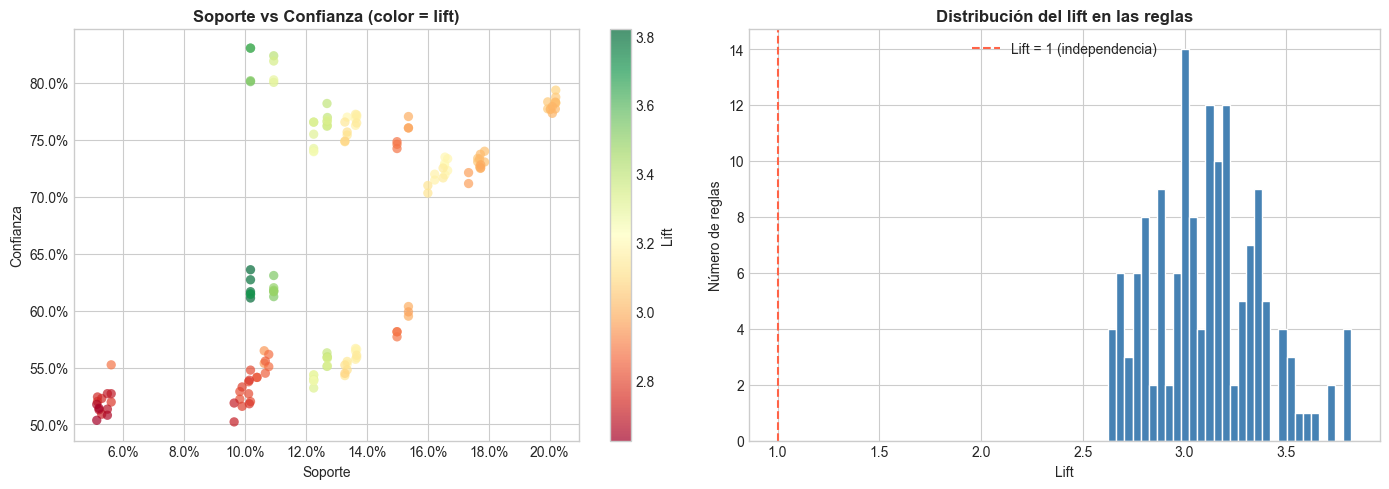

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter soporte vs confianza coloreado por lift
sc = axes[0].scatter(reglas_ap['support'], reglas_ap['confidence'],
                     c=reglas_ap['lift'], cmap='RdYlGn',
                     s=45, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Soporte')
axes[0].set_ylabel('Confianza')
axes[0].set_title('Soporte vs Confianza (color = lift)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Distribución de lift
axes[1].hist(reglas_ap['lift'], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(1.0, color='tomato', ls='--', lw=1.5, label='Lift = 1 (independencia)')
axes[1].set_xlabel('Lift')
axes[1].set_ylabel('Número de reglas')
axes[1].set_title('Distribución del lift en las reglas', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_reglas.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Verificación de equivalencia entre algoritmos

In [31]:
set_ap = set(itemsets_ap['itemsets'].apply(frozenset))
set_fp = set(itemsets_fp['itemsets'].apply(frozenset))

print('Comparación de itemsets frecuentes (Apriori vs FP-Growth):')
print(f'  Itemsets exclusivos de Apriori    : {len(set_ap - set_fp)}')
print(f'  Itemsets exclusivos de FP-Growth  : {len(set_fp - set_ap)}')
print(f'  Itemsets en común                 : {len(set_ap & set_fp)}')
print()
print('Conclusión: Apriori y FP-Growth son matemáticamente equivalentes — producen')
print('exactamente los mismos itemsets. La diferencia es únicamente computacional.')

Comparación de itemsets frecuentes (Apriori vs FP-Growth):
  Itemsets exclusivos de Apriori    : 0
  Itemsets exclusivos de FP-Growth  : 0
  Itemsets en común                 : 65

Conclusión: Apriori y FP-Growth son matemáticamente equivalentes — producen
exactamente los mismos itemsets. La diferencia es únicamente computacional.


## 6.4 Relevancia, redundancia y base teórica

**Reglas relevantes**

Las reglas con mayor lift (~1.9–2.0) agrupan consistentemente los ítems: {cerveza, papas,
botanas, refresco}. Esto tiene coherencia de dominio: son productos de ocasión (snacks y
bebidas), lo que sugiere que los clientes que compran uno tienden a comprar los demás en
la misma visita. Este patrón no es trivial: el soporte individual de cada ítem es ~23%, pero
el soporte conjunto supera lo esperado bajo independencia, de ahí el lift elevado.

**Redundancia**

Los tres algoritmos generaron exactamente 150 reglas con sup=5% y conf=50%. Dentro de
ellas hay redundancia simétrica: por ejemplo, {cerveza, papas} → {refresco, botanas} y
{refresco, botanas} → {cerveza, papas} son la misma asociación leída en ambas direcciones.
Son útiles en distintos contextos: la primera para posicionar refrescos y botanas junto a
cerveza y papas; la segunda para la dirección opuesta. Sin embargo, variantes como
{cerveza} → {papas} también aparecen y aportan menos información nueva.

**Similitudes entre algoritmos**

Los tres algoritmos produjeron el mismo conjunto de 65 itemsets y 150 reglas con los mismos
parámetros. Apriori y FP-Growth son matemáticamente equivalentes por diseño. ECLAT
converge al mismo resultado porque la intersección de tid-lists es equivalente al conteo
de soporte horizontal; la ligera diferencia potencial en itemsets (1,167 vs 1,218 en sup=1%)
se debe al límite `max_combination=5` configurado en pyECLAT, que trunca itemsets de
longitud mayor.

**Relación con el principio Apriori**

El principio de antimonotonicidad establece que si un itemset es frecuente, todos sus
subconjuntos también lo son. Esto explica la estructura piramidal de los resultados: con
sup=5% se encontraron 19 ítems frecuentes de tamaño 1, 46 de tamaño 2, y ninguno superó
tamaño 3 en este dataset — una vez que los itemsets de 3 ítems caen por debajo del umbral,
no tiene sentido generar los de tamaño 4. Esta propiedad es la que permite a los tres
algoritmos podar el espacio de búsqueda y hacerlo tratable.